In [1]:
import torch
from torch.utils.data import Dataset

import clip
import umap

from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

from tqdm.notebook import tqdm
import json, os

from shared import make_dataloader, plot_bar, visualize_umap_features, set_neurips_style

set_neurips_style()

# Task 1 - Zero-Shot Classification on STL-10

In [2]:
BASE = "stl10-data"
BASE_PLOTS = os.path.join(BASE, "plots")
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 32
CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

os.makedirs(BASE_PLOTS, exist_ok=True)

with open(f"{BASE}/test.json", "r") as f:
    labels = json.loads(f.read())

In [3]:
# should be 0-9
assert min(map(lambda x: x["label"], labels)) == 0
assert max(map(lambda x: x["label"], labels)) == 9
assert len(labels) == 8_000

In [4]:
img2label = {entry["file"]: entry["label"] for entry in labels}

In [5]:
ordered_images = [f'test_images/{img}' for img in os.listdir(f"{BASE}/test_images/")]
ordered_labels = [img2label[img] for img in ordered_images]
ordered_images = [f"{BASE}/{img}" for img in ordered_images]

In [6]:
class STL10KaggleDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

In [7]:
model, preprocess = clip.load("ViT-B/32", device=DEVICE)

In [8]:
dataset = STL10KaggleDataset(ordered_images, ordered_labels, preprocess)
dataloader, dataset_size = make_dataloader(dataset, batch_size=BATCH_SIZE, n_workers=12)

In [9]:
def get_text_features(prompt_fn=lambda x: x):
    prompts = [prompt_fn(c) for c in CLASS_NAMES]
    tokens = clip.tokenize(prompts).to(DEVICE)

    with torch.no_grad():
        text_features = normalize(model.encode_text(tokens))

    return text_features

def get_image_features(image):
    with torch.no_grad():
        image_features = model.encode_image(image)
    return image_features

def normalize(vector):
    return vector / vector.norm(dim=-1, keepdim=True)

def compute_similarity(image_features, text_features):
    return (100.0 * image_features @ text_features.T)

def get_topN(image_features, text_features, N=3):
    similarity = compute_similarity(normalize(image_features), normalize(text_features))
    values, indices = similarity.topk(N, dim=-1)
    return values, indices

In [10]:
def compute_zero_shot_accuracy(fname, dataloader, prompt_fn, image_fn=lambda x: x):
    was_training = model.training
    model.eval()
    
    metrics = {
        "actual": [],
        "predicted_top3": [],
        "confidence_top3": [],
    }
    text_features = get_text_features(prompt_fn)
    
    with torch.no_grad():
        for i, (image, actual) in tqdm(enumerate(dataloader), total=len(dataloader)):
            # image_fn is for Part 3 when applying rotation matrix
            image_features = image_fn(get_image_features(image.to(DEVICE, non_blocking=True)))
            
            values, indices = get_topN(image_features, text_features)
            
            metrics["actual"].extend(actual.tolist())
            metrics["predicted_top3"].extend(indices.cpu().tolist())
            metrics["confidence_top3"].extend(values.cpu().tolist())
        
    with open(f"{fname}.json", "w") as f:
        f.write(json.dumps(metrics))
    
    if was_training:
        model.train()
    
    return metrics

In [11]:
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_simple-label"), dataloader, prompt_fn=lambda x: x);

  0%|          | 0/250 [00:00<?, ?it/s]

In [12]:
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_plain-prompt"), dataloader, prompt_fn=lambda x: f"A photo of a {x}.");

  0%|          | 0/250 [00:00<?, ?it/s]

In [13]:
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_detailed-prompt"), dataloader, prompt_fn=lambda x: f"A photo captured of a {x}. The {x} is the main subject and centered in the frame. The photo was captured spontaneously in the wild.");

  0%|          | 0/250 [00:00<?, ?it/s]

In [4]:
def read_accuracies(fnames):
    accuracies = {}
    for fname in fnames:
        with open(os.path.join(BASE, f"{fname}.json"), "r") as f:
            pred = json.loads(f.read())

        pred_df = pd.DataFrame(pred)
        label = fname.split("_")[-1]
        
        pred_df["predicted"] = pred_df["predicted_top3"].map(lambda x: x[0])
        accuracy = (pred_df["predicted"]==pred_df["actual"]).mean()
        accuracies[label] = accuracy
    return accuracies

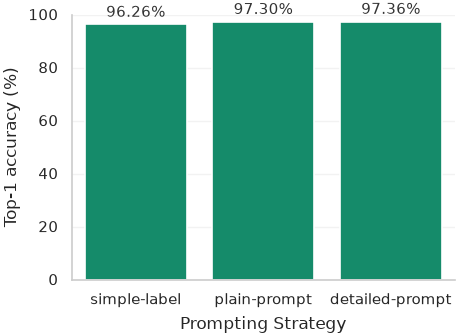

In [6]:
accuracies = read_accuracies(["clip-task_simple-label", "clip-task_plain-prompt", "clip-task_detailed-prompt"])
color = sns.color_palette("colorblind")[2]
fig, ax = plot_bar(list(map(lambda x: x*100, accuracies.values())), accuracies.keys(),
         xlabel="Prompting Strategy", ylabel="Top-1 accuracy (%)", fmt="%.2f%%",
         color=color,
         figsize=(3.25, 2.4))
ax.set_ylim(0,100)

plt.savefig(os.path.join(BASE_PLOTS, "clip-task_prompting-strategy-comparison.pdf"), bbox_inches="tight", dpi=300)
plt.show();

# 2. Exploring the Modality Gap

In [11]:
# batch size is 32, but assignment requires 50-100 subset
subset_images, subset_labels = next(iter(dataloader))
subset_images_2, subset_labels_2 = next(iter(dataloader))

# 32+32 = 64 images
subset_images = torch.concat([subset_images, subset_images_2]).to(DEVICE, non_blocking=True)
subset_labels = torch.concat([subset_labels, subset_labels_2]).to(DEVICE, non_blocking=True)

In [12]:
prompt_embs = get_text_features()
label_embs = torch.stack([prompt_embs[i] for i in subset_labels])
image_embs = get_image_features(subset_images)

In [17]:
def get_joint_space_embs(image_embs, label_embs, subset_labels):
    joint_embs = torch.cat([image_embs, label_embs], dim=0)
    joint_labels = torch.cat([subset_labels, subset_labels], dim=0)

    reducer = umap.UMAP(random_state=42, n_jobs=1)
    joint_embs = reducer.fit_transform(joint_embs.detach().cpu().numpy())

    n = len(image_embs)
    image_embedding = joint_embs[:n]
    text_embedding = joint_embs[n:]

    return image_embedding, text_embedding

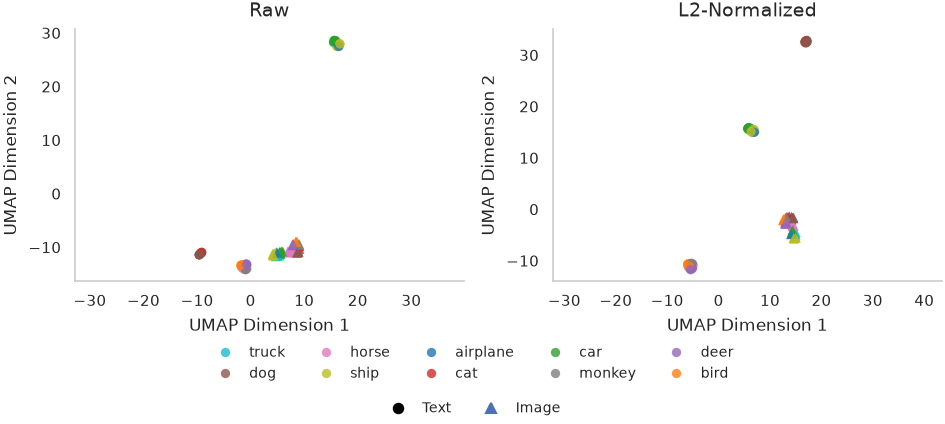

In [46]:
CLASS_PALETTE = dict(zip(CLASS_NAMES, sns.color_palette("tab10", len(CLASS_NAMES))))
TEXT_ALPHA = 0.8
IMAGE_ALPHA = 0.8

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.7))

image_embedding, text_embedding = get_joint_space_embs(image_embs, label_embs, subset_labels)
visualize_umap_features(
    features=None,
    embedding=text_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[0],
    # title="Text",
    palette=CLASS_PALETTE,
    legend=True,
    marker="o",
    point_size=20,
    alpha=TEXT_ALPHA,
)

visualize_umap_features(
    features=None,
    embedding=image_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[0],
    title="Raw",
    palette=CLASS_PALETTE,
    legend=False,
    marker="^",
    point_size=22,
    alpha=IMAGE_ALPHA,
)

image_embedding, text_embedding = get_joint_space_embs(normalize(image_embs), normalize(label_embs), subset_labels)
visualize_umap_features(
    features=None,
    embedding=text_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[1],
    # title="Text (normalized)",
    palette=CLASS_PALETTE,
    legend=False,
    marker="o",
    point_size=20,
    alpha=TEXT_ALPHA,
)

visualize_umap_features(
    features=None,
    embedding=image_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[1],
    title="L2-Normalized",
    palette=CLASS_PALETTE,
    legend=False,
    marker="^",
    point_size=22,
    alpha=IMAGE_ALPHA,
)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=6.5,
    bbox_to_anchor=(0.5, -0.01),
)

modality_handles = [
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=4.5, label="Text"),
    plt.Line2D([0], [0], marker="^", linestyle="None", markersize=4.5, label="Image"),
]

fig.legend(
    handles=modality_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=6.5,
    bbox_to_anchor=(0.5, 0.0),
)


fig.tight_layout(
    rect=[0, 0.09, 1, 1],
    w_pad=1.0,
)

fig.savefig(os.path.join(BASE_PLOTS, "clip-task_umap-raw-normalized.pdf"), bbox_inches="tight")
plt.show()


# 3. Bridging the Modality Gap

In [36]:
rotation, _ = scipy.linalg.orthogonal_procrustes(image_embs.float().cpu(), label_embs.float().cpu())

In [37]:
rotation = torch.as_tensor(rotation).to(DEVICE, non_blocking=True).half()

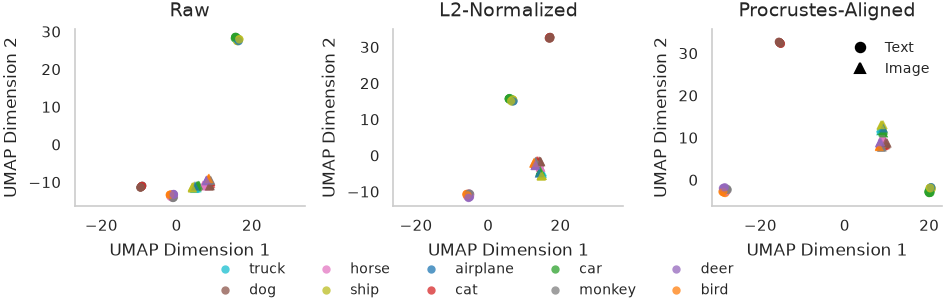

In [47]:
CLASS_PALETTE = dict(zip(CLASS_NAMES, sns.color_palette("tab10", len(CLASS_NAMES))))
TEXT_ALPHA = 0.75
IMAGE_ALPHA = 0.75
TEXT_POINT_SIZE = 16
IMAGE_POINT_SIZE = 18

fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.15))

image_embedding, text_embedding = get_joint_space_embs(image_embs, label_embs, subset_labels)
visualize_umap_features(
    features=None,
    embedding=text_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[0],
    # title="Text",
    palette=CLASS_PALETTE,
    legend=True,
    marker="o",
    point_size=TEXT_POINT_SIZE,
    alpha=TEXT_ALPHA,
)

visualize_umap_features(
    features=None,
    embedding=image_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[0],
    title="Raw",
    palette=CLASS_PALETTE,
    legend=False,
    marker="^",
    point_size=IMAGE_POINT_SIZE,
    alpha=IMAGE_ALPHA,
)

image_embedding, text_embedding = get_joint_space_embs(normalize(image_embs), normalize(label_embs), subset_labels)
visualize_umap_features(
    features=None,
    embedding=text_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[1],
    # title="Text (normalized)",
    palette=CLASS_PALETTE,
    legend=False,
    marker="o",
    point_size=TEXT_POINT_SIZE,
    alpha=TEXT_ALPHA,
)

visualize_umap_features(
    features=None,
    embedding=image_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[1],
    title="L2-Normalized",
    palette=CLASS_PALETTE,
    legend=False,
    marker="^",
    point_size=IMAGE_POINT_SIZE,
    alpha=IMAGE_ALPHA,
)

image_embedding, text_embedding = get_joint_space_embs((image_embs @ rotation), label_embs, subset_labels)
visualize_umap_features(
    features=None,
    embedding=text_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[2],
    # title="Text",
    palette=CLASS_PALETTE,
    legend=False,
    marker="o",
    point_size=TEXT_POINT_SIZE,
    alpha=TEXT_ALPHA,
)

visualize_umap_features(
    features=None,
    embedding=image_embedding,
    labels=subset_labels.cpu(),
    class_names=CLASS_NAMES,
    ax=axes[2],
    title="Procrustes-Aligned",
    palette=CLASS_PALETTE,
    legend=False,
    marker="^",
    point_size=IMAGE_POINT_SIZE,
    alpha=IMAGE_ALPHA,
)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=6.5,
    bbox_to_anchor=(0.5, -0.01),
)

modality_handles = [
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=4.5, label="Text"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=4.5, label="Image"),
]

axes[2].legend(
    handles=modality_handles,
    loc="upper right",
    frameon=False,
    fontsize=6.5,
)


fig.tight_layout(
    rect=[0, 0.09, 1, 1],
    w_pad=1.0,
)

fig.savefig(os.path.join(BASE_PLOTS, "clip-task_umap-raw-normalized-rotated.pdf"), bbox_inches="tight")
plt.show()


In [48]:
def rotate_emb(embs):
    return embs @ rotation

In [49]:
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_simple-label-rotated"), dataloader, image_fn=rotate_emb, prompt_fn=lambda x: x)
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_plain-prompt-rotated"), dataloader, image_fn=rotate_emb, prompt_fn=lambda x: f"A photo of a {x}.")
compute_zero_shot_accuracy(os.path.join(BASE, "clip-task_detailed-prompt-rotated"), dataloader, image_fn=rotate_emb, prompt_fn=lambda x: f"A photo captured of a {x}. The {x} is the main subject and centered in the frame. The photo was captured spontaneously in the wild.");

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

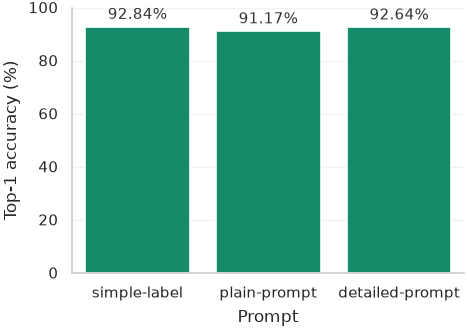

In [9]:
accuracies = read_accuracies(["clip-task_simple-label-rotated", "clip-task_plain-prompt-rotated", "clip-task_detailed-prompt-rotated"])
color = sns.color_palette("colorblind")[2]
fig, ax = plot_bar(
    list(map(lambda x: x*100, accuracies.values())),
    map(lambda x: x.replace("-rotated", ""), accuracies.keys()),
    title=None,
    xlabel="Prompt",
    ylabel="Top-1 accuracy (%)", fmt="%.2f%%",
    figsize=(3.25, 2.4),
    color=color)
ax.set_ylim(0,100)

plt.savefig(os.path.join(BASE_PLOTS, "clip-task_prompting-strategy-comparison-rotated.pdf"), bbox_inches="tight", dpi=300)
plt.show()

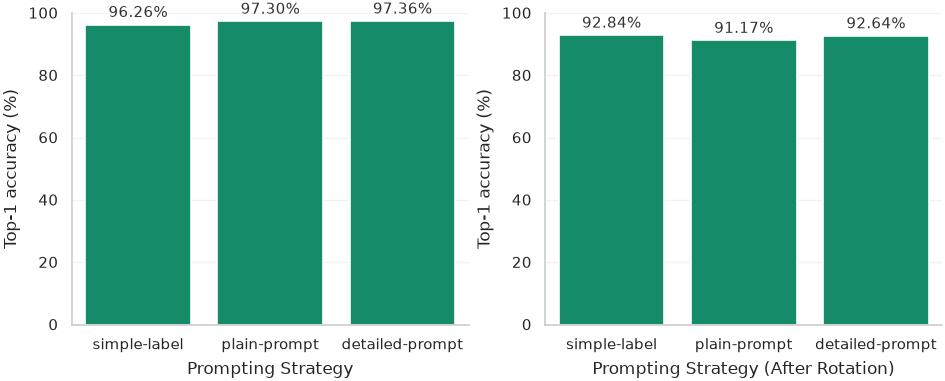

In [16]:
accuracies = read_accuracies(["clip-task_simple-label", "clip-task_plain-prompt", "clip-task_detailed-prompt"])
accuracies_rotated = read_accuracies(["clip-task_simple-label-rotated", "clip-task_plain-prompt-rotated", "clip-task_detailed-prompt-rotated"])

color = sns.color_palette("colorblind")[2]
fig, axes = plt.subplots(1,2,figsize=(6.5, 2.7))
axes = axes.ravel()

plot_bar(list(map(lambda x: x*100, accuracies.values())), accuracies.keys(),
         xlabel="Prompting Strategy", ylabel="Top-1 accuracy (%)", fmt="%.2f%%",
         color=color,
         fig=fig, ax=axes[0])
plot_bar(list(map(lambda x: x*100, accuracies_rotated.values())), map(lambda x: x.replace("-rotated", ""), accuracies_rotated.keys()),
         xlabel="Prompting Strategy (After Rotation)", ylabel="Top-1 accuracy (%)", fmt="%.2f%%",
         color=color,
         fig=fig, ax=axes[1])

axes[0].set_ylim(0,100)
axes[1].set_ylim(0,100)

plt.savefig(os.path.join(BASE_PLOTS, "clip-task_prompting-strategy-comparison-rotated-vs-original.pdf"), bbox_inches="tight", dpi=300)
plt.show();